In [1]:
%load_ext autoreload
%autoreload 2

# EDA — Precipitation Nowcasting From Space

**目標**：理解資料結構與分布，為模型設計提供依據。

執行前請先設定下方的 `DATA_DIR` 與 `CSV_TRAIN`。

In [2]:
from pathlib import Path

DATA_DIR  = Path("/Volumes/T7/new_code/solafune/data")
CSV_TRAIN = DATA_DIR / "train_dataset.csv"

## 1. 套件匯入

In [3]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 2. CSV 基本資訊

In [5]:
df = pd.read_csv(CSV_TRAIN)
print(f"Total samples : {len(df)}")
df.head()

Total samples : 40686


,unique_id,name_location,satellite_target,datetime,last_30_minutes_observation_filename,gpm_imerg_filename
0,c901-207d,aceh,himawari,2023-01-01 00:00:00,"['train_aceh_Himawari_20221231_2330.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_00-00-00.tif
1,3311-9497,aceh,himawari,2023-01-01 00:30:00,"['train_aceh_Himawari_20230101_0000.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_00-30-00.tif
2,ae46-e82d,aceh,himawari,2023-01-01 01:00:00,"['train_aceh_Himawari_20230101_0030.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_01-00-00.tif
3,6ca6-b8d8,aceh,himawari,2023-01-01 01:30:00,"['train_aceh_Himawari_20230101_0100.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_01-30-00.tif
4,20a1-eba0,aceh,himawari,2023-01-01 02:00:00,"['train_aceh_Himawari_20230101_0130.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_02-00-00.tif


In [7]:
df.columns

Index(['unique_id', 'name_location', 'satellite_target', 'datetime',
       'last_30_minutes_observation_filename', 'gpm_imerg_filename'],
      dtype='str')

In [9]:
print("=== Satellite 分布 ===")
print(df['satellite_target'].value_counts())

=== Satellite 分布 ===
satellite_target
meteosat    17222
himawari    13192
goes        10272
Name: count, dtype: int64


In [10]:
print("\n=== Location 分布 ===")
print(df['name_location'].value_counts())




=== Location 分布 ===
name_location
france                   7167
atlantic_coast           2928
ecuador                  2928
aceh                     2926
andalusia                2900
bahia_blanca             1488
bihar                    1488
dhaka                    1488
guangdong                1488
jakarta                  1488
jamaica                  1488
cape_town                1465
gaza_province            1465
florida                  1440
central_philippines      1438
central_vietnam          1438
hat_yai                  1438
friuli_venezia_giulia    1423
kinshasa                 1421
borno_state              1381
Name: count, dtype: int64


In [11]:
print("\n=== 時間範圍 ===")
print(f"  Start : {df['datetime'].min()}")
print(f"  End   : {df['datetime'].max()}")


=== 時間範圍 ===
  Start : 2023-01-01 00:00:00
  End   : 2026-01-31 21:30:00


Q: 下面這個 code block 在做什麼？

In [13]:
import ast

frame_counts = df['last_30_minutes_observation_filename'].apply(
    lambda x: len(ast.literal_eval(x))
)
print("=== 每筆 frame 數量 ===")
print(frame_counts.value_counts().sort_index())

=== 每筆 frame 數量 ===
last_30_minutes_observation_filename
0      235
1        8
2      647
3    39796
Name: count, dtype: int64


## 3. 降水量（GPM-IMERG）分布分析

這是最重要的 EDA：了解 target 的分布形狀，決定是否需要 `log1p` transform。

In [14]:
import ast
from tqdm import tqdm

SATELLITE_SUBDIR = {'himawari': 'himawari', 'goes': 'goes', 'meteosat': 'meteosat'}

sample_rows = df.sample(min(100, len(df)), random_state=0)
precip_vals = []
for _, row in tqdm(sample_rows.iterrows(), total=len(sample_rows), desc="Reading GPM"):
    with rasterio.open(DATA_DIR / "gpm_imerg" / row['gpm_imerg_filename']) as src:
        arr = src.read(1).ravel()
    precip_vals.append(arr)

precip = np.concatenate(precip_vals)

print("=== 降水量統計（mm/hr）===")
print(f"  zero fraction : {(precip == 0).mean():.2%}")
print(f"  mean          : {precip.mean():.4f}")
print(f"  std           : {precip.std():.4f}")
print(f"  max           : {precip.max():.4f}")
print(f"  99th pct      : {np.percentile(precip, 99):.4f}")
print(f"  99.9th pct    : {np.percentile(precip, 99.9):.4f}")

Reading GPM: 100%|██████████| 100/100 [00:00<00:00, 248.94it/s]

=== 降水量統計（mm/hr）===
  zero fraction : 80.33%
  mean          : 0.3348
  std           : 1.4836
  max           : 39.9600
  99th pct      : 7.4000
  99.9th pct    : 18.1170


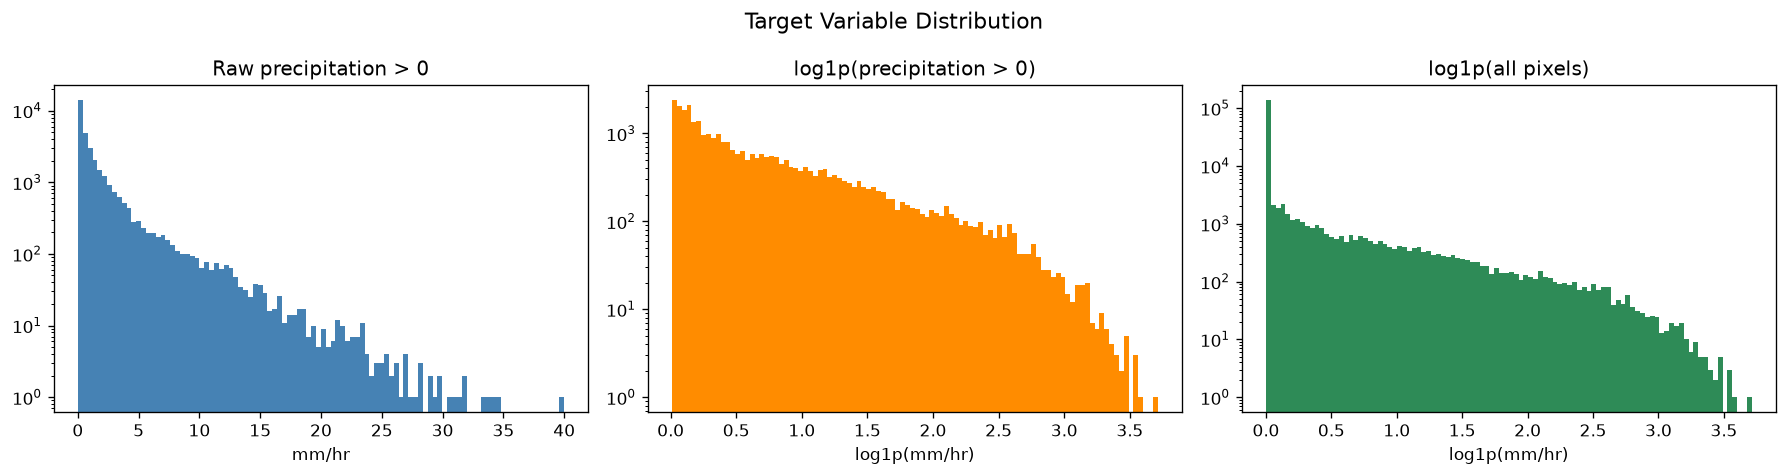

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 原始值（非零）
nz = precip[precip > 0]
axes[0].hist(nz, bins=100, log=True, color='steelblue')
axes[0].set_title('Raw precipitation > 0')
axes[0].set_xlabel('mm/hr')

# log1p 變換
axes[1].hist(np.log1p(nz), bins=100, log=True, color='darkorange')
axes[1].set_title('log1p(precipitation > 0)')
axes[1].set_xlabel('log1p(mm/hr)')

# 包含零值的完整分布（log1p）
axes[2].hist(np.log1p(precip), bins=100, log=True, color='seagreen')
axes[2].set_title('log1p(all pixels)')
axes[2].set_xlabel('log1p(mm/hr)')

plt.suptitle('Target Variable Distribution', fontsize=13)
plt.tight_layout()
plt.show()

Q: 從上面這三個圖我們可以得到什麼資訊？ 

## 4. 衛星影像波段可視化

In [16]:
import ast

SATELLITE_SUBDIR = {'himawari': 'himawari', 'goes': 'goes', 'meteosat': 'meteosat'}

def plot_all_bands(row, title=None):
    sat = row['satellite_target']
    fname = ast.literal_eval(row['last_30_minutes_observation_filename'])[0]
    with rasterio.open(DATA_DIR / SATELLITE_SUBDIR[sat] / fname) as src:
        img = src.read().astype(np.float32)  # (16, H, W)

    print(f"Image shape : {img.shape}")
    print(f"Value range : [{img.min():.2f}, {img.max():.2f}]")

    fig, axes = plt.subplots(2, 8, figsize=(20, 5))
    for b in range(16):
        ax = axes[b // 8][b % 8]
        band_data = img[b]
        vmin, vmax = np.percentile(band_data, 2), np.percentile(band_data, 98)
        ax.imshow(band_data, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(f'B{b+1}', fontsize=8)
        ax.axis('off')

    plt.suptitle(title or f"Satellite: {sat} | {row['datetime']}")
    plt.tight_layout()
    plt.show()
    return img


Satellite: himawari
Image shape : (16, 81, 81)
Value range : [0.00, 221.00]


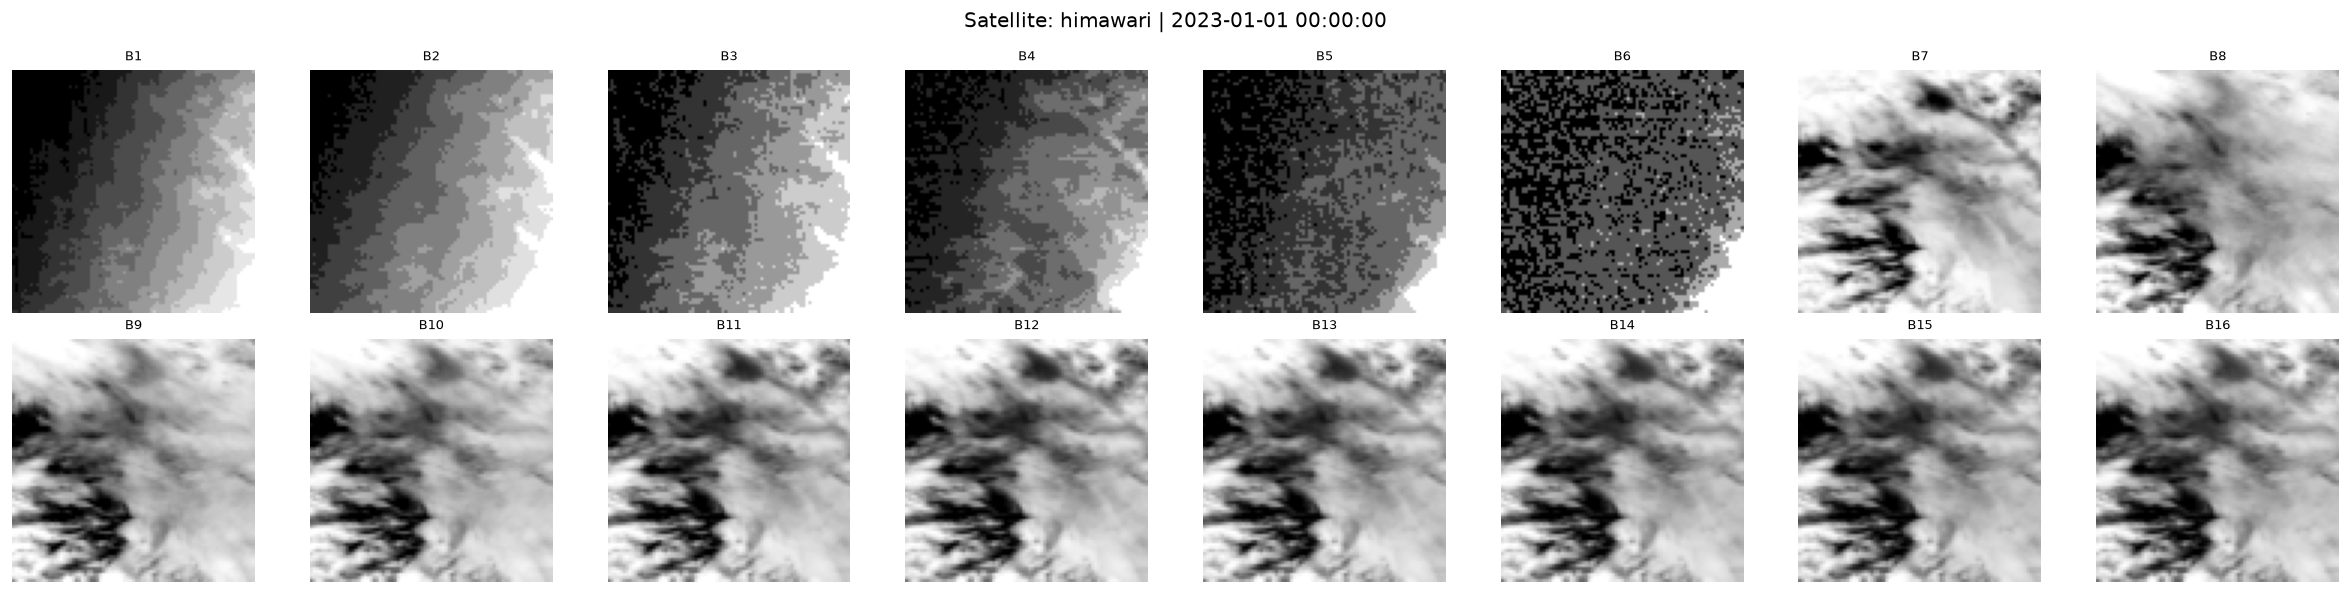


Satellite: meteosat
Image shape : (16, 144, 144)
Value range : [0.00, 225.00]


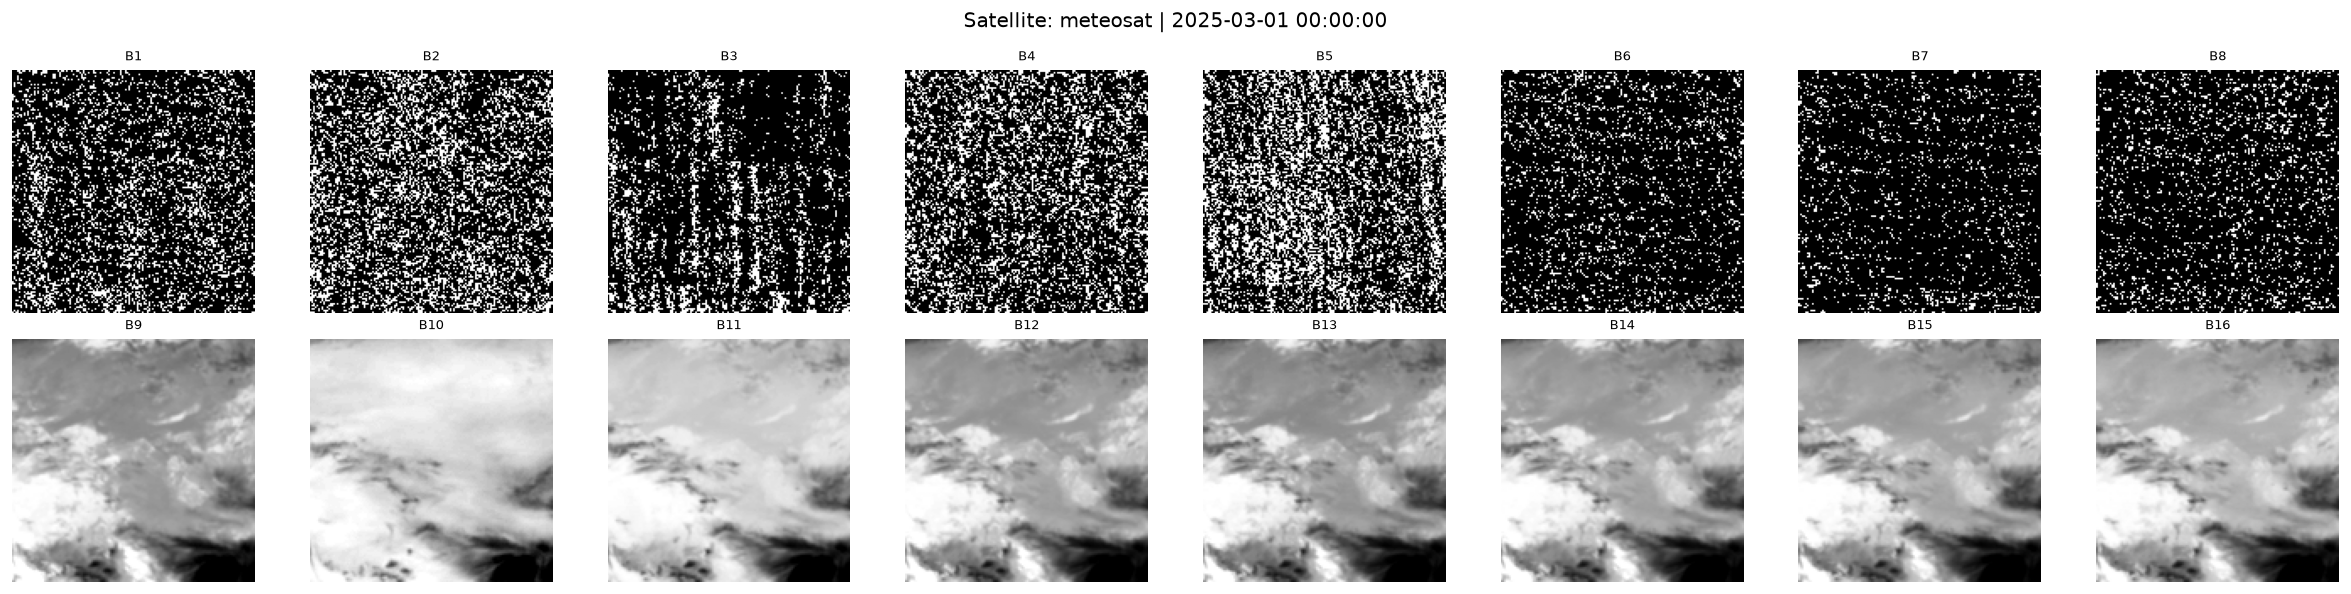


Satellite: goes
Image shape : (16, 141, 141)
Value range : [0.00, 253.00]


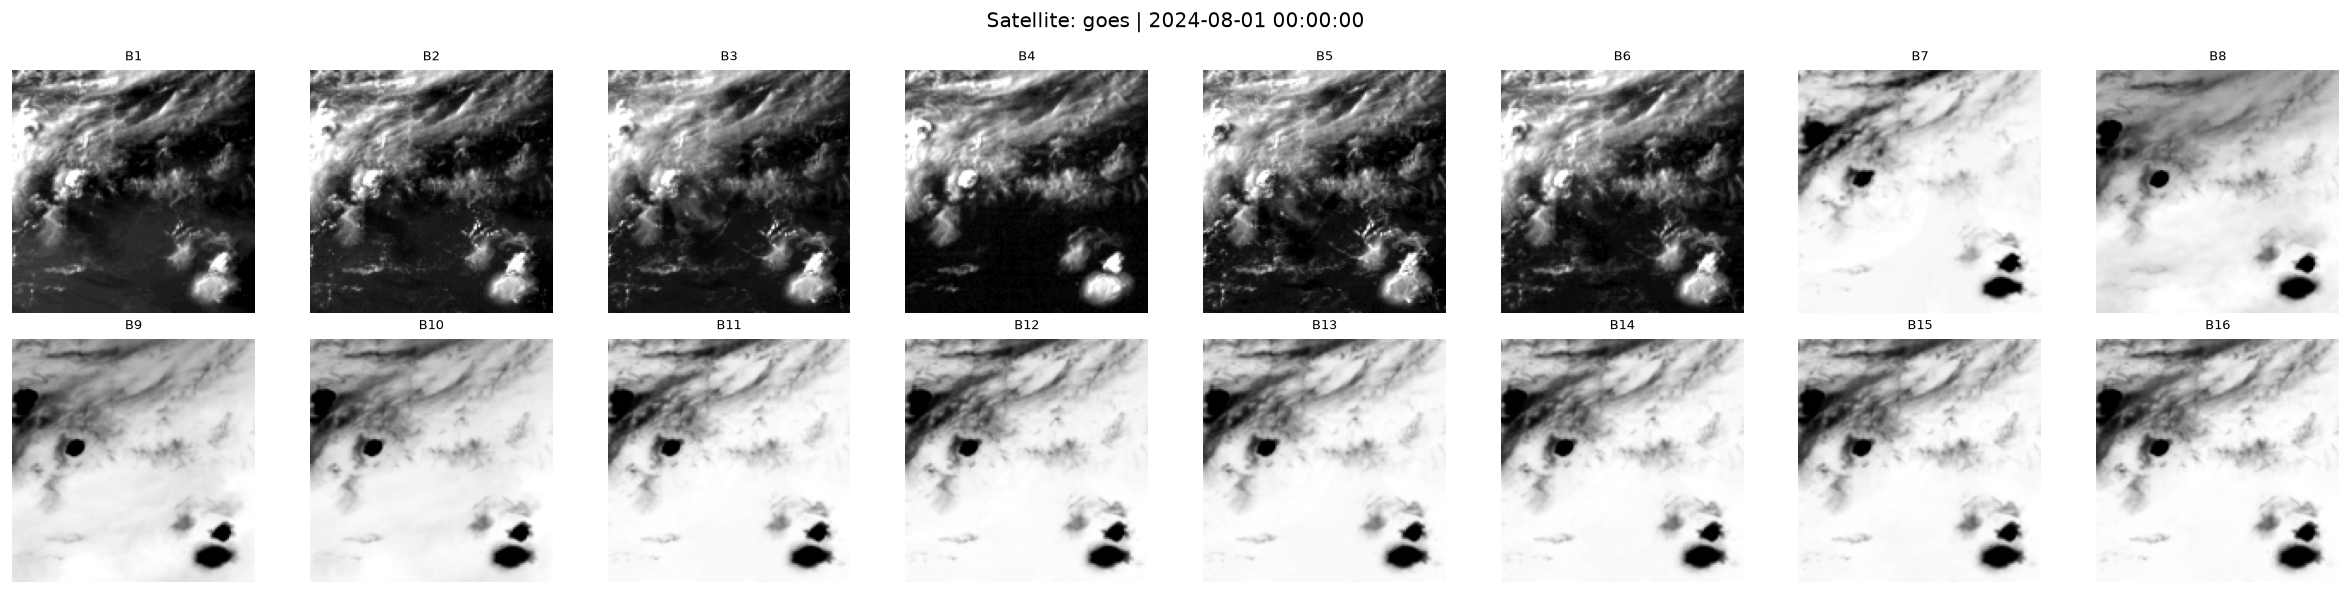

In [17]:
# 各衛星各看一個樣本
for sat in df['satellite_target'].unique():
    row = df[df['satellite_target'] == sat].iloc[0]
    print(f"\n{'='*50}")
    print(f"Satellite: {sat}")
    _ = plot_all_bands(row)

Q: 從上面這個 plotting & 看 value range 的過程我們得到什麼資訊？ 

## 5. 波段數值範圍統計（跨衛星比較）

了解不同衛星的數值範圍，確認標準化的必要性。

In [18]:
from collections import defaultdict
import ast
from tqdm import tqdm

SATELLITE_SUBDIR = {'himawari': 'himawari', 'goes': 'goes', 'meteosat': 'meteosat'}
sat_stats = defaultdict(lambda: defaultdict(list))

for sat in df['satellite_target'].unique():
    sub = df[df['satellite_target'] == sat].sample(min(20, len(df[df['satellite_target'] == sat])), random_state=0)
    for _, row in tqdm(sub.iterrows(), total=len(sub), desc=f"{sat}"):
        fnames = ast.literal_eval(row['last_30_minutes_observation_filename'])
        fname = fnames[0]
        fpath = DATA_DIR / SATELLITE_SUBDIR[sat] / fname
        if not fpath.exists():
            continue
        with rasterio.open(fpath) as src:
            arr = src.read().astype(np.float32)
        for b in range(arr.shape[0]):
            sat_stats[sat][b].append(arr[b].ravel()[::5])

print(f"{'Satellite':<12} {'Band':>4} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print('-' * 58)
for sat, bands in sat_stats.items():
    for b, vals in sorted(bands.items()):
        v = np.concatenate(vals)
        print(f"{sat:<12} {b+1:>4} {v.mean():>10.2f} {v.std():>10.2f} {v.min():>10.2f} {v.max():>10.2f}")

goes: 100%|██████████| 20/20 [00:02<00:00,  9.18it/s]

Satellite    Band       Mean        Std        Min        Max
----------------------------------------------------------
himawari        1      36.29      56.17       0.00     244.00
himawari        2      34.16      53.91       0.00     238.00
himawari        3      31.79      52.01       0.00     237.00
himawari        4      35.43      56.17       0.00     238.00
himawari        5      24.11      37.42       0.00     167.00
himawari        6      20.06      33.29       0.00     134.00
himawari        7     157.85      40.48       4.00     254.00
himawari        8     157.45      51.29       0.00     255.00
himawari        9     167.28      50.93       0.00     255.00
himawari       10     175.01      50.63       0.00     251.00
himawari       11     175.54      54.24       0.00     252.00
himawari       12     157.80      50.58       0.00     251.00
himawari       13     173.07      54.86       0.00     250.00
himawari       14     171.44      56.22       0.00     249.00
himawari   

Q: 從上面這邊的結果我們得到什麼資訊？ 
1) 是否需要標準化
2) 要怎麼標準化？ 

## 6. 衛星影像 vs 降水量 對照

視覺化確認 IR 波段（雲頂溫度）與降水的相關性。

Q: 
從下面這邊我們可以得到什麼資訊？
1. 看一個例子好像太少了？ 

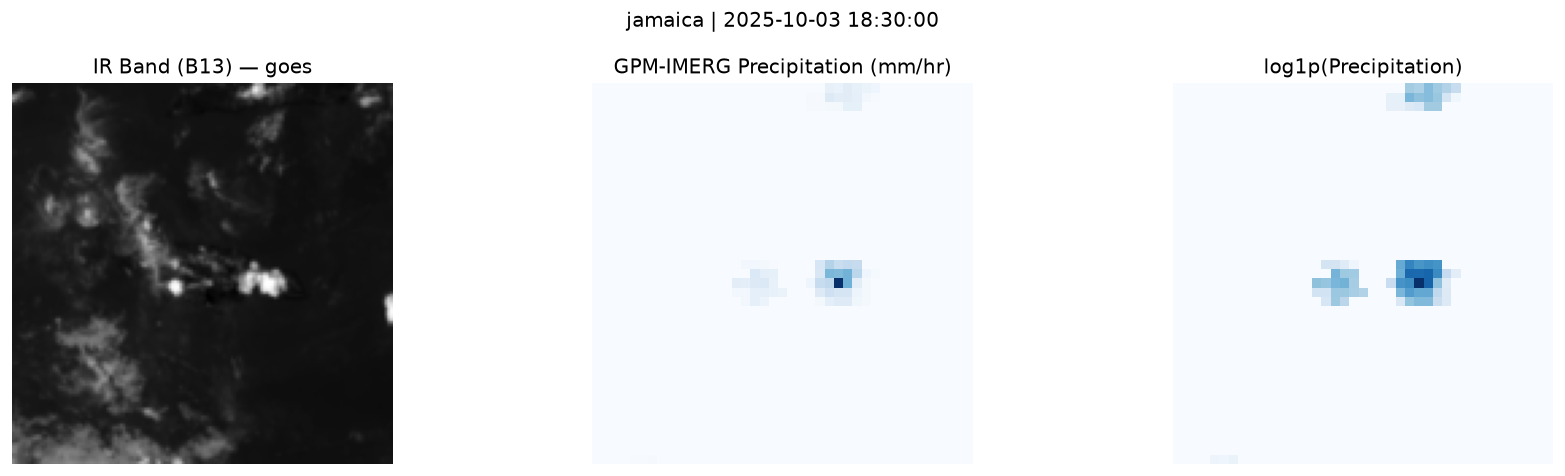

Satellite        : goes
Max precipitation: 29.73 mm/hr
Rain coverage    : 4.46% of pixels


In [20]:
import ast
from tqdm import tqdm

SATELLITE_SUBDIR = {'himawari': 'himawari', 'goes': 'goes', 'meteosat': 'meteosat'}

def find_rainy_sample(df, data_dir, n_try=100):
    for _, row in df.sample(min(n_try, len(df)), random_state=1).iterrows():
        gpm_path = data_dir / "gpm_imerg" / row['gpm_imerg_filename']
        if not gpm_path.exists():
            continue
        sat = row['satellite_target']
        fnames = ast.literal_eval(row['last_30_minutes_observation_filename'])
        if not fnames:
            continue
        sat_path = data_dir / SATELLITE_SUBDIR[sat] / fnames[0]
        if not sat_path.exists():
            continue
        with rasterio.open(gpm_path) as src:
            target = src.read(1)
        if target.max() > 1.0:
            return row, target
    return None, None

row, target = find_rainy_sample(df, DATA_DIR)

if row is not None:
    sat = row['satellite_target']
    fname = ast.literal_eval(row['last_30_minutes_observation_filename'])[0]
    with rasterio.open(DATA_DIR / SATELLITE_SUBDIR[sat] / fname) as src:
        img = src.read().astype(np.float32)

    ir_band = img[12]  # B13 / C13 / ir_105 → 雲頂溫度

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(ir_band, cmap='gray_r')
    axes[0].set_title(f'IR Band (B13) — {sat}')
    axes[0].axis('off')

    axes[1].imshow(target, cmap='Blues')
    axes[1].set_title('GPM-IMERG Precipitation (mm/hr)')
    axes[1].axis('off')

    axes[2].imshow(np.log1p(target), cmap='Blues')
    axes[2].set_title('log1p(Precipitation)')
    axes[2].axis('off')

    plt.suptitle(f"{row['name_location']} | {row['datetime']}")
    plt.tight_layout()
    plt.show()

    print(f"Satellite        : {sat}")
    print(f"Max precipitation: {target.max():.2f} mm/hr")
    print(f"Rain coverage    : {(target > 0).mean():.2%} of pixels")
else:
    print("找不到有明顯降水的樣本，請增加 n_try 或確認本地有足夠 sample TIF。")

## 7. 小結與後續行動

填入 EDA 後的觀察，用來指導 Week 1–2 的設計決策。

In [13]:
# EDA 結論整理
notes = """
=== EDA 觀察記錄 ===

1. 降水分布：
   - 零值佔比：80.33%
   - mean：0.3348 mm/hr  |  std：1.4836  |  max：39.96 mm/hr
   - 99th pct：7.4 mm/hr  |  99.9th pct：18.12 mm/hr
   - log1p transform：有效（壓縮長尾偏態分布，必要）

2. 各衛星樣本數（訓練集共 40,686 筆）：
   - Himawari : 13,192 筆
   - GOES     : 10,272 筆
   - Meteosat : 17,222 筆

3. 影像解析度（H × W）：
   - Himawari :  81 × 81
   - GOES     : 141 × 141
   - Meteosat : 144 × 144
   → 三顆衛星解析度不同，Dataset 內各自獨立處理（不需統一 resize）

4. 波段數值範圍：
   - 三顆衛星均為 0–255 整數編碼
   - 需要標準化：Yes（per-satellite per-band z-score）
   - VIS 波段（B1–B6）夜間為 0（非 NaN）

5. frame 數量分布（過去 30 分鐘觀測）：
   - 3 frames：39,796 筆（97.8%，主要情況）
   - 2 frames：647 筆
   - 1 frame ：8 筆
   - 0 frames：235 筆（需 padding mask 處理）

6. IR 波段（B13）vs 降水的相關性：
   - 高降水區對應低亮溫（雲頂高 → 低溫），符合物理預期
   - log1p(precipitation) 視覺對比更清晰

7. 其他觀察：
   - Meteosat 在本地僅有 sample TIF，band stats 需在 Vast.ai 上完整計算
   - goes / himawari train TIF 本地有完整或接近完整的樣本
"""
print(notes)


=== EDA 觀察記錄 ===

1. 降水分布：
   - 零值佔比：80.33%
   - mean：0.3348 mm/hr  |  std：1.4836  |  max：39.96 mm/hr
   - 99th pct：7.4 mm/hr  |  99.9th pct：18.12 mm/hr
   - log1p transform：有效（壓縮長尾偏態分布，必要）

2. 各衛星樣本數（訓練集共 40,686 筆）：
   - Himawari : 13,192 筆
   - GOES     : 10,272 筆
   - Meteosat : 17,222 筆

3. 影像解析度（H × W）：
   - Himawari :  81 × 81
   - GOES     : 141 × 141
   - Meteosat : 144 × 144
   → 三顆衛星解析度不同，Dataset 內各自獨立處理（不需統一 resize）

4. 波段數值範圍：
   - 三顆衛星均為 0–255 整數編碼
   - 需要標準化：Yes（per-satellite per-band z-score）
   - VIS 波段（B1–B6）夜間為 0（非 NaN）

5. frame 數量分布（過去 30 分鐘觀測）：
   - 3 frames：39,796 筆（97.8%，主要情況）
   - 2 frames：647 筆
   - 1 frame ：8 筆
   - 0 frames：235 筆（需 padding mask 處理）

6. IR 波段（B13）vs 降水的相關性：
   - 高降水區對應低亮溫（雲頂高 → 低溫），符合物理預期
   - log1p(precipitation) 視覺對比更清晰

7. 其他觀察：
   - Meteosat 在本地僅有 sample TIF，band stats 需在 Vast.ai 上完整計算
   - goes / himawari train TIF 本地有完整或接近完整的樣本

